In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset/Powdery Mildew/IMG_20211107_124627 (Custom).jpg
/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset/Powdery Mildew/IMG_20211107_125226 (Custom).jpg
/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset/Powdery Mildew/IMG_20211107_125656 (Custom).jpg
/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset/Powdery Mildew/IMG_20211107_125157 (Custom).jpg
/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset/Powdery Mildew/20211109_121933 (Custom).jpg
/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset/Powdery Mildew/IMG_20211107_125339 (Custom).jpg
/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset/Powdery Mildew/IMG_20211107_115649 (Custom).jpg
/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset/Powdery Mildew/20211109_122151(0) (Custom).jpg
/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset/Powdery Mildew/20211109_122241 (Custom).jpg
/kaggle/input/datasets/aryas

## required libraries

In [2]:
!pip install -q torchinfo thop codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 9.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 94.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.1 MB/s eta 0:00:00:00:01


## importing libraries

In [3]:
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

from torchinfo import summary
from thop import profile
from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")

## device config

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


## random seed

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

## dataset

In [6]:
dataset_path = "/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset"

print(dataset_path)

/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset


## image transforms

In [7]:
IMG_SIZE = 240
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8, 1.0)
    ),
    
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


## loading data

In [8]:
full_dataset = datasets.ImageFolder(root=dataset_path)

class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Total images: {len(full_dataset)}")

Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Number of classes: 8
Total images: 4000


## splitting data

In [9]:
indices = list(range(len(full_dataset)))

random.shuffle(indices)

train_split = int(0.7 * len(indices))
val_split = int(0.85 * len(indices))

train_indices = indices[:train_split]
val_indices = indices[train_split:val_split]
test_indices = indices[val_split:]

print(f"Train size: {len(train_indices)}")
print(f"Validation size: {len(val_indices)}")
print(f"Test size: {len(test_indices)}")

Train size: 2800
Validation size: 600
Test size: 600


## creating the datasets

In [10]:
train_dataset_full = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transforms
)

test_dataset_full = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transforms
)

train_dataset = Subset(
    train_dataset_full,
    train_indices
)

val_dataset = Subset(
    test_dataset_full,
    val_indices
)

test_dataset = Subset(
    test_dataset_full,
    test_indices
)

## dataloaders

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


## images samples

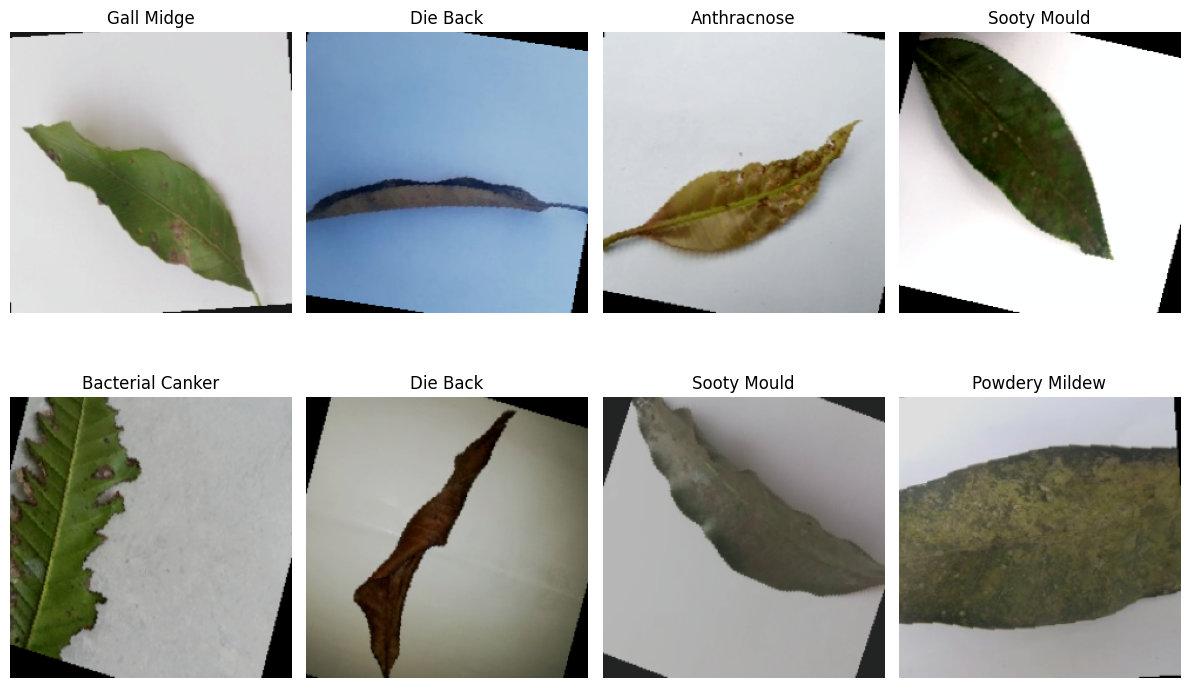

In [12]:
def imshow(img):

    img = img.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.axis("off")

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    imshow(images[i])

    plt.title(class_names[labels[i]])

plt.tight_layout()
plt.show()

## efficientnet-b1 model

In [13]:
model = models.efficientnet_b1(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    
    nn.Dropout(0.4),
    
    nn.Linear(in_features, 512),
    nn.ReLU(),
    
    nn.Dropout(0.3),
    
    nn.Linear(512, num_classes)
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 104MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## model summary

In [14]:
summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 8]                    --
├─Sequential: 1-1                                       [1, 1280, 8, 8]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 120, 120]         --
│    │    └─Conv2d: 3-1                                 [1, 32, 120, 120]         (864)
│    │    └─BatchNorm2d: 3-2                            [1, 32, 120, 120]         (64)
│    │    └─SiLU: 3-3                                   [1, 32, 120, 120]         --
│    └─Sequential: 2-2                                  [1, 16, 120, 120]         --
│    │    └─MBConv: 3-4                                 [1, 16, 120, 120]         (1,448)
│    │    └─MBConv: 3-5                                 [1, 16, 120, 120]         (612)
│    └─Sequential: 2-3                                  [1, 24, 60, 60]           --
│    │    └─MBConv: 3-6                        

## loss function & optimizer

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)


## training config

In [16]:
EPOCHS = 15

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0

## training loop

In [17]:
tracker = EmissionsTracker()
tracker.start()

start_time = time.time()

for epoch in range(EPOCHS):

    # ================= TRAINING =================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_acc)

    # ================= VALIDATION =================

    model.eval()

    val_running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_acc = 100 * correct / total

    val_losses.append(val_loss)

    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    # Save Best Model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_mango_effb1.pth"
        )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

training_time = time.time() - start_time

emissions = tracker.stop()

print("\nTraining Complete.")

[codecarbon WARNING @ 14:20:26] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 14:20:26] [setup] RAM Tracking...
[codecarbon INFO @ 14:20:26] [setup] CPU Tracking...
[codecarbon WARNING @ 14:20:27] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 14:20:27] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 14:20:27] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 14:20:27] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 14:20:27] [setup] GPU Tracking...
[codecarbon INFO @ 14:20:27] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 14:20:27] The below tracking methods have been set up:
                RAM Tracking Method: RAM p

Epoch [1/15] | Train Loss: 0.4925 | Train Acc: 85.21% | Val Loss: 0.1145 | Val Acc: 98.00%


[codecarbon INFO @ 14:21:16] Energy consumed for RAM : 0.000250 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 14:21:16] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 14:21:16] Energy consumed for All CPU : 0.000531 kWh
[codecarbon INFO @ 14:21:16] Energy consumed for all GPUs : 0.000631 kWh. Total GPU Power : 52.50124719766377 W
[codecarbon INFO @ 14:21:16] 0.001412 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 14:21:31] Energy consumed for RAM : 0.000333 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 14:21:31] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 14:21:31] Energy consumed for All CPU : 0.000708 kWh
[codecarbon INFO @ 14:21:31] Energy consumed for all GPUs : 0.000851 kWh. Total GPU Power : 52.93093889223595 W
[codecarbon INFO @ 14:21:31] 0.001892 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch [2/15] | Train Loss: 0.1505 | Train Acc: 95.00% | Val Loss: 0.0891 | Val Acc: 98.33%


[codecarbon INFO @ 14:21:46] Energy consumed for RAM : 0.000416 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 14:21:46] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 14:21:46] Energy consumed for All CPU : 0.000885 kWh
[codecarbon INFO @ 14:21:46] Energy consumed for all GPUs : 0.001086 kWh. Total GPU Power : 56.31148929608777 W
[codecarbon INFO @ 14:21:46] 0.002387 kWh of electricity and 0.000000 L of water were used since the beginning.


...

Epoch [13/15] | Train Loss: 0.0685 | Train Acc: 97.64% | Val Loss: 0.0396 | Val Acc: 98.67%


[codecarbon INFO @ 14:26:31] Energy consumed for RAM : 0.001998 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 14:26:31] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 14:26:31] Energy consumed for All CPU : 0.004247 kWh
[codecarbon INFO @ 14:26:31] Energy consumed for all GPUs : 0.005753 kWh. Total GPU Power : 61.49049252531319 W
[codecarbon INFO @ 14:26:31] 0.011998 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 14:26:31] 0.004719 g.CO2eq/s mean an estimation of 148.81087441149162 kg.CO2eq/year
[codecarbon INFO @ 14:26:46] Energy consumed for RAM : 0.002082 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 14:26:46] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 14:26:46] Energy consumed for All CPU : 0.004424 kWh
[codecarbon INFO @ 14:26:46] Energy consumed for all GPUs : 0.006000 kWh. Total GPU Power : 59.19311293767744 W
[codecarbon INFO @ 14:26:46] 0.01

Epoch [14/15] | Train Loss: 0.0562 | Train Acc: 97.96% | Val Loss: 0.0350 | Val Acc: 99.17%


[codecarbon INFO @ 14:27:01] Energy consumed for RAM : 0.002165 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 14:27:01] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 14:27:01] Energy consumed for All CPU : 0.004601 kWh
[codecarbon INFO @ 14:27:01] Energy consumed for all GPUs : 0.006248 kWh. Total GPU Power : 59.74178458100743 W
[codecarbon INFO @ 14:27:01] 0.013014 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 14:27:12] Energy consumed for RAM : 0.002226 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 14:27:12] Delta energy consumed for CPU with constant : 0.000130 kWh, power : 42.5 W
[codecarbon INFO @ 14:27:12] Energy consumed for All CPU : 0.004730 kWh
[codecarbon INFO @ 14:27:12] Energy consumed for all GPUs : 0.006433 kWh. Total GPU Power : 60.62156764295378 W
[codecarbon INFO @ 14:27:12] 0.013390 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch [15/15] | Train Loss: 0.0591 | Train Acc: 97.93% | Val Loss: 0.0318 | Val Acc: 99.00%

Training Complete.


## learning curves

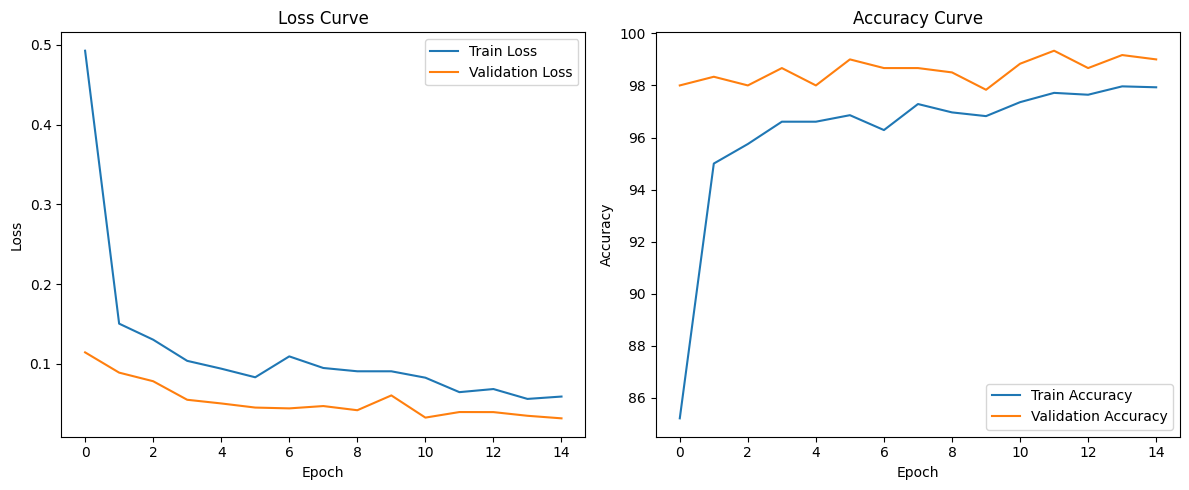

In [18]:
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy Curve")

plt.legend()

plt.tight_layout()
plt.show()

## loading best model

In [19]:
model.load_state_dict(torch.load("best_mango_effb1.pth"))

model.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## model evaluation

In [20]:
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

## classification metrics

In [21]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

kappa = cohen_kappa_score(
    all_labels,
    all_preds
)

labels_binarized = label_binarize(
    all_labels,
    classes=range(num_classes)
)

roc_auc = roc_auc_score(
    labels_binarized,
    all_probs,
    multi_class='ovr'
)

print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"Cohen Kappa  : {kappa:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")

Accuracy     : 0.9917
Precision    : 0.9918
Recall       : 0.9917
F1 Score     : 0.9917
Cohen Kappa  : 0.9905
ROC-AUC      : 1.0000


## classsification report

In [22]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names
)

print(report)

                  precision    recall  f1-score   support

     Anthracnose       0.99      0.98      0.98        89
Bacterial Canker       1.00      1.00      1.00        79
  Cutting Weevil       0.99      1.00      0.99        74
        Die Back       1.00      1.00      1.00        67
      Gall Midge       0.97      1.00      0.99        75
         Healthy       1.00      0.99      0.99        76
  Powdery Mildew       1.00      0.98      0.99        66
     Sooty Mould       0.99      0.99      0.99        74

        accuracy                           0.99       600
       macro avg       0.99      0.99      0.99       600
    weighted avg       0.99      0.99      0.99       600



## confusion matrix

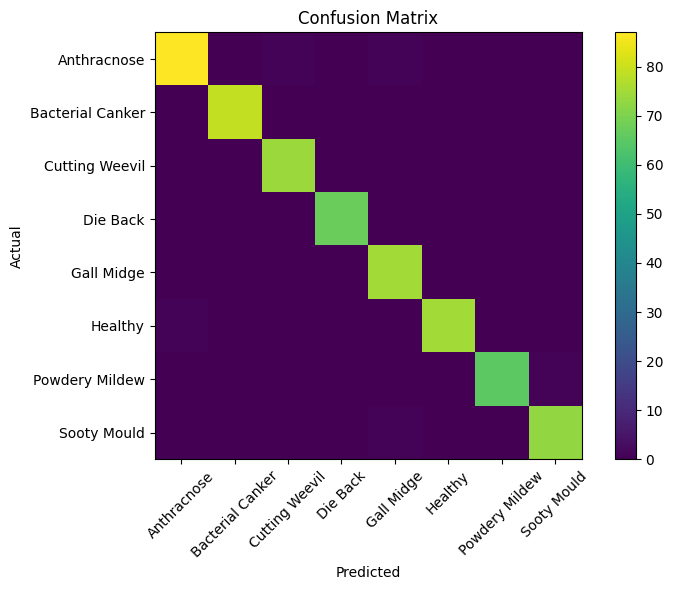

In [23]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation='nearest')

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    rotation=45
)

plt.yticks(
    tick_marks,
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## FLOPs & parameters

In [24]:
dummy_input = torch.randn(
    1,
    3,
    IMG_SIZE,
    IMG_SIZE
).to(device)

flops, params = profile(
    model,
    inputs=(dummy_input,),
    verbose=False
)

print(f"FLOPs      : {flops / 1e9:.3f} GFLOPs")
print(f"Parameters : {params / 1e6:.3f} Million")

FLOPs      : 0.734 GFLOPs
Parameters : 7.173 Million


## energy & carbon emissions

In [25]:
print(f"Training Time       : {training_time:.2f} seconds")
print(f"Carbon Emissions    : {emissions:.6f} kgCO2eq")

Training Time       : 401.00 seconds
Carbon Emissions    : 0.001858 kgCO2eq
